# Payment system BCRP

In [53]:
import sys
from functools import reduce

import numpy as np
import pandas as pd
import requests

sys.path.append("..")
sys.path.append("../..")
import catppuccin
import matplotlib.pyplot as plt

from src.utils import build_bcrp_dataset, get_bcrp_clean_series

pd.options.display.float_format = "{:,.2f}".format
pd.set_option("display.max_columns", None)

# TODO: create a visualization.py
plt.style.use("mocha")

In [3]:
metadata = pd.read_csv("../../data/BCRPData-metadata.csv", encoding="latin1", sep=";")

## Instrumentos de pagos de alto y bajo valor: Monto de operaciones (Millones de Soles)

**How is the payment system structuraly composed?**

- how money moves
- through which payment instrument

In [ ]:
# we include ALL the codes inside the category "Sistema de pagos - instrumentos de pagos de alto y bajo valor: monto de operaciones (milllones de soles)"
codes_names = {
    "PN42156EM": "alto_valor",
    "PN42157EM": "alto_valor_lbtr",
    "PN42158EM": "alto_valor_lbtr_clientes",
    "PN42159EM": "alto_valor_lbtr_propias",
    "PN42160EM": "bajo_valor",
    "PN42161EM": "bajo_valor_cheques",
    "PN42162EM": "bajo_valor_cheques_intrabancarios",
    "PN42163EM": "bajo_valor_cheques_interbancarios_cce",
    "PN42164EM": "bajo_valor_tarjetas_pago",
    "PN42165EM": "bajo_valor_tarjetas_debito",
    "PN42166EM": "bajo_valor_tarjetas_debito_no_presencial",
    "PN42167EM": "bajo_valor_tarjetas_debito_presencial",
    "PN42168EM": "bajo_valor_tarjetas_credito",
    "PN42169EM": "bajo_valor_tarjetas_credito_no_presencial",
    "PN42170EM": "bajo_valor_tarjetas_credito_presencial",
    "PN42171EM": "bajo_valor_transferencias_intrabancarias",
    "PN42172EM": "bajo_valor_transferencias_intrabancarias_no_presencial",
    "PN42173EM": "bajo_valor_transferencias_intrabancarias_presencial",
    "PN42174EM": "bajo_valor_transferencias_interbancarias",
    "PN42175EM": "bajo_valor_transferencias_cce",
    "PN42176EM": "bajo_valor_pagos_inmediatos",
    "PN42177EM": "bajo_valor_pagos_inmediatos_cce",
    "PN42178EM": "bajo_valor_pagos_inmediatos_visa_direct",
    "PN42179EM": "bajo_valor_debitos_directos",
    "PN42180EM": "bajo_valor_dinero_electronico",
    "PN42181EM": "indicador_pagos_digitales",
    "PN42182EM": "retiro_efectivo",
    "PN42183EM": "retiro_efectivo_tarjetas_debito",
    "PN42184EM": "retiro_efectivo_tarjetas_credito",
}

In [ ]:
# we create a dataframe with all the inforamtion in that gruup
df_instr_alto_bajo_valor = build_bcrp_dataset(codes_names)

In [83]:
df_instr_alto_bajo_valor[df_instr_alto_bajo_valor["period"] == "2025-03-01"].head(5)

,period,alto_valor,alto_valor_lbtr,alto_valor_lbtr_clientes,alto_valor_lbtr_propias,bajo_valor,bajo_valor_cheques,bajo_valor_cheques_intrabancarios,bajo_valor_cheques_interbancarios_cce,bajo_valor_tarjetas_pago,bajo_valor_tarjetas_debito,bajo_valor_tarjetas_debito_no_presencial,bajo_valor_tarjetas_debito_presencial,bajo_valor_tarjetas_credito,bajo_valor_tarjetas_credito_no_presencial,bajo_valor_tarjetas_credito_presencial,bajo_valor_transferencias_intrabancarias,bajo_valor_transferencias_intrabancarias_no_presencial,bajo_valor_transferencias_intrabancarias_presencial,bajo_valor_transferencias_interbancarias,bajo_valor_transferencias_cce,bajo_valor_pagos_inmediatos,bajo_valor_pagos_inmediatos_cce,bajo_valor_pagos_inmediatos_visa_direct,bajo_valor_debitos_directos,bajo_valor_dinero_electronico,indicador_pagos_digitales,retiro_efectivo,retiro_efectivo_tarjetas_debito,retiro_efectivo_tarjetas_credito,bajo_valor_calculated,residual
12,2025-03-01,"445,419.59","445,419.59","243,713.56","201,706.02","326,013.42","15,260.98","7,815.60","7,445.38","16,418.70","7,598.00","2,673.81","4,924.19","8,820.70","1,982.17","6,838.53","236,435.00","220,421.65","16,013.35","56,021.48","26,983.28","29,038.20","19,488.93","9,549.27",872.51,"1,004.74","554,466.01","35,223.01","34,588.65",634.37,"326,013.42",-0.00


In [ ]:
df_instr_alto_bajo_valor["bajo_valor_calculated"] = df_instr_alto_bajo_valor[
    [
        "bajo_valor_cheques",
        "bajo_valor_tarjetas_pago",
        "bajo_valor_transferencias_intrabancarias",
        "bajo_valor_transferencias_interbancarias",
        "bajo_valor_debitos_directos",
        "bajo_valor_dinero_electronico",
    ]
].sum(axis=1)
df_instr_alto_bajo_valor["residual"] = (
    df_instr_alto_bajo_valor["bajo_valor"]
    - df_instr_alto_bajo_valor["bajo_valor_calculated"]
)

In [29]:
df_instr_alto_bajo_valor[
    ["period", "bajo_valor", "bajo_valor_calculated", "residual"]
].head(5)

,period,bajo_valor,bajo_valor_calculated,residual
0,2026-03-01,"417,155.45","417,155.45",-0.00
1,2026-02-01,"377,297.19","377,297.19",0.00
2,2026-01-01,"394,384.29","394,384.29",0.00
3,2025-12-01,"458,953.59","458,953.59",-0.00
4,2025-11-01,"374,481.11","374,481.11",0.00


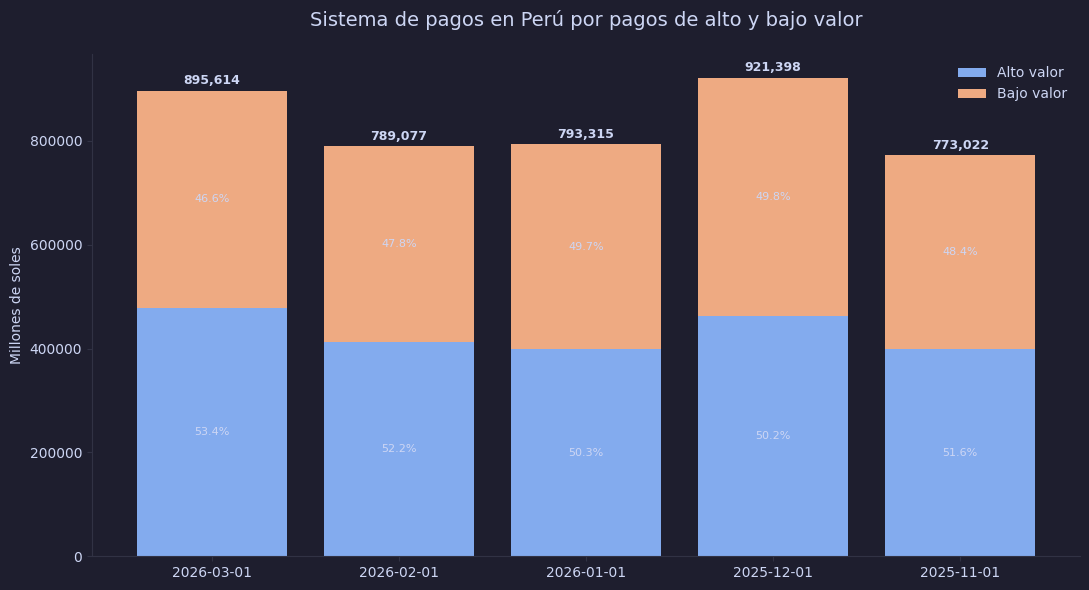

In [41]:
df_plot = (
    df_instr_alto_bajo_valor[["period", "alto_valor", "bajo_valor"]]
    .query("period >= '2025-11-01'")
    .copy()
)

df_plot["total"] = df_plot["alto_valor"] + df_plot["bajo_valor"]

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    df_plot["period"].astype(str), df_plot["alto_valor"], label="Alto valor", alpha=0.95
)

ax.bar(
    df_plot["period"].astype(str),
    df_plot["bajo_valor"],
    bottom=df_plot["alto_valor"],
    label="Bajo valor",
    alpha=0.95,
)

for i, row in df_plot.reset_index().iterrows():

    ax.text(
        i,
        row["total"] * 1.015,
        f'{row["total"]:,.0f}',
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

    ax.text(
        i,
        row["alto_valor"] / 2,
        f'{row["alto_valor"] / row["total"]:.1%}',
        ha="center",
        va="center",
        fontsize=8,
    )

    ax.text(
        i,
        row["alto_valor"] + row["bajo_valor"] / 2,
        f'{row["bajo_valor"] / row["total"]:.1%}',
        ha="center",
        va="center",
        fontsize=8,
    )

ax.set_title(
    "Sistema de pagos en Perú por pagos de alto y bajo valor", fontsize=14, pad=20
)

ax.set_ylabel("Millones de soles")
ax.set_xlabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

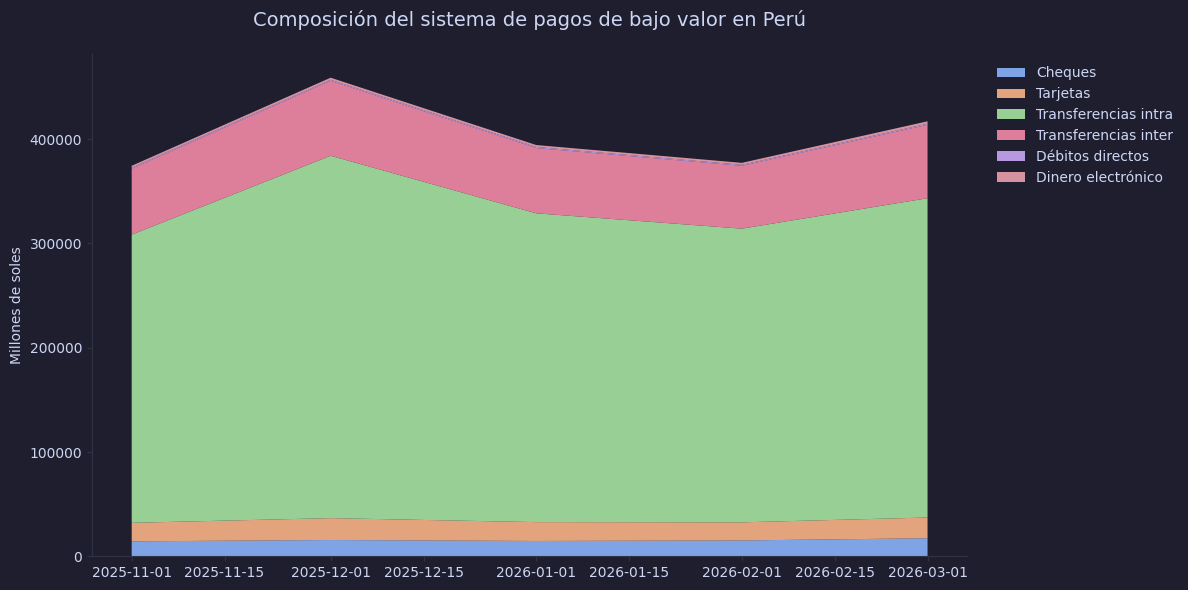

In [46]:
df_plot = (
    df_instr_alto_bajo_valor[
        [
            "period",
            "bajo_valor_cheques",
            "bajo_valor_tarjetas_pago",
            "bajo_valor_transferencias_intrabancarias",
            "bajo_valor_transferencias_interbancarias",
            "bajo_valor_debitos_directos",
            "bajo_valor_dinero_electronico",
        ]
    ]
    .query("period >= '2025-11-01'")
    .copy()
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.stackplot(
    df_plot["period"],
    df_plot["bajo_valor_cheques"],
    df_plot["bajo_valor_tarjetas_pago"],
    df_plot["bajo_valor_transferencias_intrabancarias"],
    df_plot["bajo_valor_transferencias_interbancarias"],
    df_plot["bajo_valor_debitos_directos"],
    df_plot["bajo_valor_dinero_electronico"],
    labels=[
        "Cheques",
        "Tarjetas",
        "Transferencias intra",
        "Transferencias inter",
        "Débitos directos",
        "Dinero electrónico",
    ],
    alpha=0.9,
)

ax.set_title(
    "Composición del sistema de pagos de bajo valor en Perú", fontsize=14, pad=20
)

ax.set_ylabel("Millones de soles")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

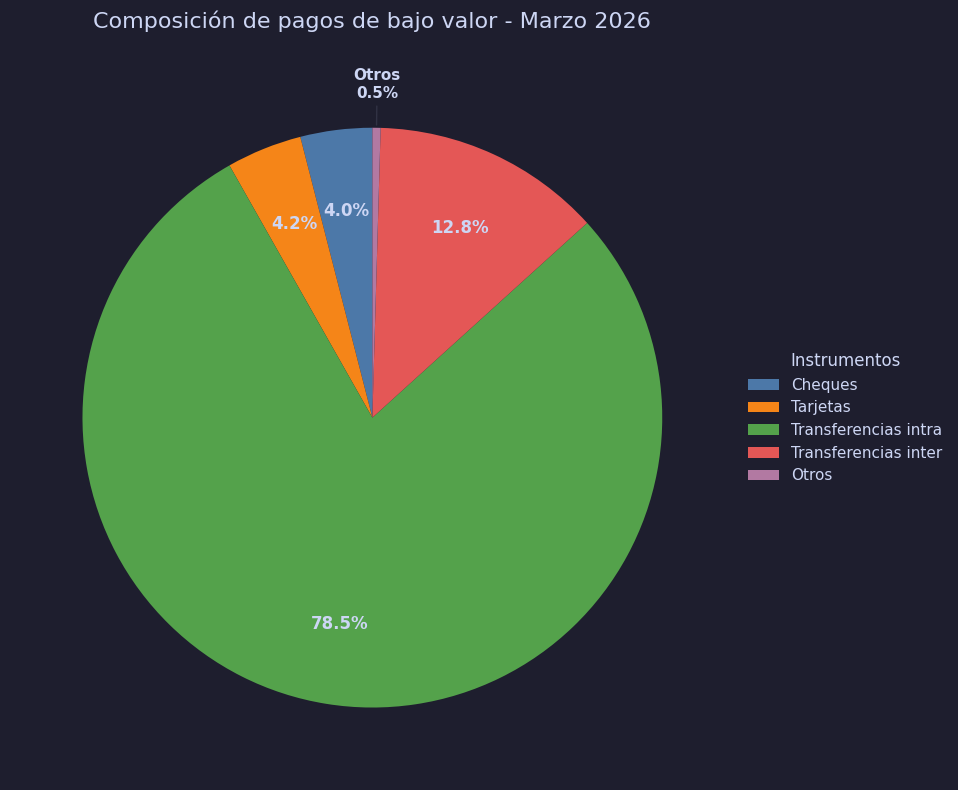

In [73]:
colors = [
    "#4c78a8",
    "#f58518",
    "#54a24b",
    "#e45756",
    "#b279a2",
]

df_pie = df_instr_alto_bajo_valor[
    df_instr_alto_bajo_valor["period"] == pd.Timestamp("2024-03-01")
]

otros = (
    df_pie["bajo_valor_debitos_directos"].values[0]
    + df_pie["bajo_valor_dinero_electronico"].values[0]
)

labels = [
    "Cheques",
    "Tarjetas",
    "Transferencias intra",
    "Transferencias inter",
    "Otros",
]

values = [
    df_pie["bajo_valor_cheques"].values[0],
    df_pie["bajo_valor_tarjetas_pago"].values[0],
    df_pie["bajo_valor_transferencias_intrabancarias"].values[0],
    df_pie["bajo_valor_transferencias_interbancarias"].values[0],
    otros,
]

fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    values,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    startangle=90,
    pctdistance=0.72,
    textprops={"fontsize": 12},
    colors=colors,
)

otros_pct = values[-1] / sum(values) * 100
wedge = wedges[-1]

angle = (wedge.theta2 + wedge.theta1) / 2

x = 1.15 * np.cos(np.deg2rad(angle))
y = 1.15 * np.sin(np.deg2rad(angle))

ax.annotate(
    f"Otros\n{otros_pct:.1f}%",
    xy=(np.cos(np.deg2rad(angle)), np.sin(np.deg2rad(angle))),
    xytext=(x, y),
    fontsize=11,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=dict(arrowstyle="-"),
)

for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight("bold")

ax.legend(
    wedges,
    labels,
    title="Instrumentos",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    fontsize=11,
    title_fontsize=12,
)

ax.set_title(
    "Composición de pagos de bajo valor - Marzo 2026",
    fontsize=16,
    pad=20,
)

plt.tight_layout()
plt.show()

## Medios de pago distintos al efectivo, cajeros y banca virtual: Monto de las operaciones en MN (millones S/) 

**How are users accessing and udinsg financial products and servcies?**

- This is not system structure, is from the consumer't pov
- How do they replace cash?
- retail payment behavior

**IMPORTNAT ACTUALLY DEPRECRATED OR NOT UPDATED SINCE 2025 FOR SOEM IMPORTANT SERIES**

In [66]:
codes_names_montos_medios_pago = {
    "PN09398SM": "cheques_cobrados_ventanilla",
    "PN09399SM": "cheques_depositados_cuenta",
    "PN09401SM": "tarjetas_debito",
    "PN09404SM": "tarjetas_credito",
    "PN09407SM": "transferencias_credito",
    "PN09409SM": "transferencias_credito_cce",
    "PN09411SM": "debitos_directos_misma_entidad",
    "PN09412SM": "cajeros_automaticos",
    "PN09413SM": "cajeros_automaticos_retiro_efectivo",
    "PN09414SM": "cajeros_automaticos_pagos",
    "PN09415SM": "banca_virtual",
    "PN09416SM": "banca_virtual_pagos",
}

In [67]:
df_nocash_mn = build_bcrp_dataset(codes_names_montos_medios_pago)

In [68]:
df_nocash_mn.head(5)

,period,cheques_cobrados_ventanilla,cheques_depositados_cuenta,tarjetas_debito,tarjetas_credito,transferencias_credito,transferencias_credito_cce,debitos_directos_misma_entidad,cajeros_automaticos,cajeros_automaticos_retiro_efectivo,cajeros_automaticos_pagos,banca_virtual,banca_virtual_pagos
0,2026-03-01,"3,808.47","1,807.16",NaN,NaN,NaN,NaN,NaN,"14,866.51","14,608.82",257.69,NaN,NaN
1,2026-02-01,"3,406.29","1,435.79",NaN,NaN,NaN,NaN,NaN,"13,636.89","13,402.91",233.99,NaN,NaN
2,2026-01-01,"3,750.81","1,270.24",NaN,NaN,NaN,NaN,NaN,"14,696.31","14,446.30",250.01,NaN,NaN
3,2025-12-01,"4,656.88","1,466.10",NaN,NaN,NaN,NaN,NaN,"17,806.20","17,503.56",302.64,NaN,NaN
4,2025-11-01,"3,730.35","1,306.41",NaN,NaN,NaN,NaN,NaN,"14,557.47","14,308.28",249.18,NaN,NaN


# Pagos de alto y bajo valor (millones S/) 

**How much economy activity flows through the peruvian payment system?**

- Macro payment perspective


In [75]:
codes_names_pago_alto_y_bajo = {
    # "PN39932SM": "alto_valor",
    # "PN39933SM": "alto_valor_lbtr",
    # "PN39934SM": "alto_valor_lbtr_clientes",
    # "PN39935SM": "alto_valor_lbtr_propias",
    "PN39936SM": "bajo_valor",
    "PN39937SM": "bajo_valor_transferencias_intrabancarias",
    "PN39938SM": "bajo_valor_transferencias_intrabancarias_billeteras",
    "PN39939SM": "bajo_valor_transferencias_intrabancarias_otros_canales",
    "PN39940SM": "bajo_valor_transferencias_interbancarias_billeteras",
    "PN39941SM": "bajo_valor_sistema_cce",
    "PN39942SM": "bajo_valor_cce_transferencias_credito",
    "PN39943SM": "bajo_valor_cce_transferencias_inmediatas",
    "PN39944SM": "bajo_valor_cce_cheques",
    "PN39945SM": "bajo_valor_tarjetas_pago",
    "PN39946SM": "bajo_valor_tarjetas_debito",
    "PN39947SM": "bajo_valor_tarjetas_credito",
    "PN39948SM": "bajo_valor_cheques_intrabancarios",
    "PN39949SM": "bajo_valor_debitos_automaticos",
    "PN39950SM": "bajo_valor_bim_pagos_transferencias",
    "PN39951SM": "indicador_pagos_digitales",
}

In [76]:
df_pago_alto_bajo = build_bcrp_dataset(codes_names_pago_alto_y_bajo)

**There are slight difference in the amoutns of the two groups, with the instrument methodology having larget amounts**

In [77]:
df_pago_alto_bajo.head(5)

,period,bajo_valor,bajo_valor_transferencias_intrabancarias,bajo_valor_transferencias_intrabancarias_billeteras,bajo_valor_transferencias_intrabancarias_otros_canales,bajo_valor_transferencias_interbancarias_billeteras,bajo_valor_sistema_cce,bajo_valor_cce_transferencias_credito,bajo_valor_cce_transferencias_inmediatas,bajo_valor_cce_cheques,bajo_valor_tarjetas_pago,bajo_valor_tarjetas_debito,bajo_valor_tarjetas_credito,bajo_valor_cheques_intrabancarios,bajo_valor_debitos_automaticos,bajo_valor_bim_pagos_transferencias,indicador_pagos_digitales
0,2025-06-01,"331,098.34","241,710.58","28,846.25","212,864.32","9,581.15","54,479.70","27,338.75","19,654.60","7,486.35","15,803.08","7,131.82","8,671.26","8,304.15",826.95,392.73,"601,021.48"
1,2025-05-01,"371,072.84","281,621.03","29,456.13","252,164.89","10,088.90","53,473.54","28,273.86","17,219.77","7,979.91","16,550.38","7,726.84","8,823.53","8,076.96",847.29,414.75,"616,003.31"
2,2025-04-01,"323,605.61","236,566.56","26,909.82","209,656.75","9,097.83","53,408.36","26,922.31","18,960.86","7,525.19","15,532.74","7,111.25","8,421.49","7,855.31",845.51,299.30,"557,273.70"
3,2025-03-01,"325,408.63","236,435.10","27,716.62","208,718.48","9,549.27","53,917.59","26,983.28","19,488.93","7,445.38","16,418.70","7,598.00","8,820.70","7,815.60",872.53,399.84,"553,861.22"
4,2025-02-01,"307,602.68","227,576.80","23,305.59","204,271.21","8,480.90","48,438.01","24,157.04","16,782.46","7,498.51","14,475.50","6,844.98","7,630.52","7,404.92",861.37,365.17,"522,708.71"


In [86]:
df_instr_alto_bajo_valor[df_instr_alto_bajo_valor["period"] <= "2025-06-01"].head(5)

,period,alto_valor,alto_valor_lbtr,alto_valor_lbtr_clientes,alto_valor_lbtr_propias,bajo_valor,bajo_valor_cheques,bajo_valor_cheques_intrabancarios,bajo_valor_cheques_interbancarios_cce,bajo_valor_tarjetas_pago,bajo_valor_tarjetas_debito,bajo_valor_tarjetas_debito_no_presencial,bajo_valor_tarjetas_debito_presencial,bajo_valor_tarjetas_credito,bajo_valor_tarjetas_credito_no_presencial,bajo_valor_tarjetas_credito_presencial,bajo_valor_transferencias_intrabancarias,bajo_valor_transferencias_intrabancarias_no_presencial,bajo_valor_transferencias_intrabancarias_presencial,bajo_valor_transferencias_interbancarias,bajo_valor_transferencias_cce,bajo_valor_pagos_inmediatos,bajo_valor_pagos_inmediatos_cce,bajo_valor_pagos_inmediatos_visa_direct,bajo_valor_debitos_directos,bajo_valor_dinero_electronico,indicador_pagos_digitales,retiro_efectivo,retiro_efectivo_tarjetas_debito,retiro_efectivo_tarjetas_credito,bajo_valor_calculated,residual
9,2025-06-01,"505,592.31","505,592.31","285,713.64","219,878.67","332,067.58","15,790.49","8,304.15","7,486.35","15,807.55","7,136.29","2,513.18","4,623.11","8,671.26","2,138.60","6,532.66","242,027.92","226,588.61","15,439.30","56,464.72","27,338.75","29,125.97","19,654.60","9,471.37",827.29,"1,149.60","601,990.72","38,037.07","37,382.05",655.02,"332,067.58",-0.00
10,2025-05-01,"466,310.46","466,310.46","260,987.34","205,323.12","374,982.56","16,056.87","8,076.96","7,979.91","16,550.38","7,726.84","2,661.04","5,065.81","8,823.53","1,978.47","6,845.06","281,621.03","264,517.96","17,103.07","58,836.47","28,273.86","30,562.62","20,473.72","10,088.90",847.29,"1,070.52","619,913.03","35,867.75","35,204.39",663.36,"374,982.56",0.00
11,2025-04-01,"473,038.34","473,038.34","249,048.59","223,989.76","324,207.14","15,380.50","7,855.31","7,525.19","15,532.72","7,111.23","2,496.94","4,614.28","8,421.49","1,967.56","6,453.93","236,567.89","219,133.27","17,434.63","54,980.13","26,921.44","28,058.69","18,960.86","9,097.83",848.18,897.71,"557,875.22","33,775.48","33,118.45",657.04,"324,207.14",0.00
12,2025-03-01,"445,419.59","445,419.59","243,713.56","201,706.02","326,013.42","15,260.98","7,815.60","7,445.38","16,418.70","7,598.00","2,673.81","4,924.19","8,820.70","1,982.17","6,838.53","236,435.00","220,421.65","16,013.35","56,021.48","26,983.28","29,038.20","19,488.93","9,549.27",872.51,"1,004.74","554,466.01","35,223.01","34,588.65",634.37,"326,013.42",-0.00
13,2025-02-01,"442,802.36","442,802.36","230,009.47","212,792.89","307,756.72","14,815.55","7,317.04","7,498.51","14,774.50","6,845.05","2,363.08","4,481.98","7,929.44","1,760.64","6,168.80","227,399.50","213,068.91","14,330.59","49,077.70","24,157.04","24,920.66","16,782.46","8,138.20",814.72,874.74,"522,950.63","33,430.37","32,852.43",577.93,"307,756.72",-0.00


### Recreating plot 1 in moneda-201 publish

In [90]:
df_pago_alto_bajo[df_pago_alto_bajo["period"] == "2024-07-01"].head(5)

,period,bajo_valor,bajo_valor_transferencias_intrabancarias,bajo_valor_transferencias_intrabancarias_billeteras,bajo_valor_transferencias_intrabancarias_otros_canales,bajo_valor_transferencias_interbancarias_billeteras,bajo_valor_sistema_cce,bajo_valor_cce_transferencias_credito,bajo_valor_cce_transferencias_inmediatas,bajo_valor_cce_cheques,bajo_valor_tarjetas_pago,bajo_valor_tarjetas_debito,bajo_valor_tarjetas_credito,bajo_valor_cheques_intrabancarios,bajo_valor_debitos_automaticos,bajo_valor_bim_pagos_transferencias,indicador_pagos_digitales
11,2024-07-01,"315,375.03","230,424.71","20,935.75","209,488.97","8,690.36","51,036.95","27,285.11","16,878.75","6,873.09","15,801.66","7,428.31","8,373.35","8,389.09",803.09,229.17,"534,184.25"


In [ ]:
# whole market given this group
df_pie = df_pago_alto_bajo[df_pago_alto_bajo["period"] == pd.Timestamp("2024-07-01")]

components = [
    "bajo_valor_transferencias_intrabancarias",
    "bajo_valor_transferencias_interbancarias_billeteras",
    "bajo_valor_sistema_cce",
    "bajo_valor_tarjetas_pago",
    "bajo_valor_cheques_intrabancarios",
    "bajo_valor_debitos_automaticos",
    "bajo_valor_bim_pagos_transferencias",
]

total_bajo_valor = df_pie["bajo_valor"].values[0]
suma_componentes = df_pie[components].sum(axis=1).values[0]

for col in components:

    value = df_pie[col].values[0]
    pct = value / total_bajo_valor * 100

    print(f"{col}: {value:,.2f} ({pct:.1f}%)")

print(
    f"\nbajo_valor: {total_bajo_valor:,.2f} vs suma componentes: {suma_componentes:,.2f}"
)
print(f"diferencia: {total_bajo_valor - suma_componentes:,.2f}")

bajo_valor_transferencias_intrabancarias: 230,424.71 (73.1%)
bajo_valor_transferencias_interbancarias_billeteras: 8,690.36 (2.8%)
bajo_valor_sistema_cce: 51,036.95 (16.2%)
bajo_valor_tarjetas_pago: 15,801.66 (5.0%)
bajo_valor_cheques_intrabancarios: 8,389.09 (2.7%)
bajo_valor_debitos_automaticos: 803.09 (0.3%)
bajo_valor_bim_pagos_transferencias: 229.17 (0.1%)

bajo_valor: 315,375.03 vs suma componentes: 315,375.03
diferencia: -0.00


In [118]:
# attemp to recreate the plot 1 shown in the publish
df_plot = df_pago_alto_bajo[
    (df_pago_alto_bajo["period"] >= "2024-01-01")
    & (df_pago_alto_bajo["period"] <= "2024-07-01")
].sum(numeric_only=True)

transferencias_billeteras = (
    df_plot["bajo_valor_transferencias_intrabancarias_billeteras"]
    + df_plot["bajo_valor_transferencias_interbancarias_billeteras"]
)

transferencias_otros_original = df_plot[
    "bajo_valor_transferencias_intrabancarias_otros_canales"
]

transferencias_cce = df_plot["bajo_valor_sistema_cce"]
tarjetas_pago = df_plot["bajo_valor_tarjetas_pago"]

cheques_intrabancarios = df_plot["bajo_valor_cheques_intrabancarios"]
debitos_automaticos = df_plot["bajo_valor_debitos_automaticos"]
bim_pagos_transferencias = df_plot["bajo_valor_bim_pagos_transferencias"]

otros_componentes = (
    transferencias_billeteras
    + transferencias_cce
    + tarjetas_pago
    # + cheques_intrabancarios
    # + debitos_automaticos
    # + bim_pagos_transferencias
)

target_share_otros = 0.49

transferencias_otros_filtrado = (target_share_otros * otros_componentes) / (
    1 - target_share_otros
)

total_minorista_filtrado = otros_componentes + transferencias_otros_filtrado

print(
    f"Transferencias vía billeteras: {transferencias_billeteras:,.2f} ({transferencias_billeteras / total_minorista_filtrado:.1%})"
)
print(
    f"Transferencias intrabancarias vía otros canales: {transferencias_otros_filtrado:,.2f} ({transferencias_otros_filtrado / total_minorista_filtrado:.1%})"
)
print(
    f"Transferencias del sistema CCE: {transferencias_cce:,.2f} ({transferencias_cce / total_minorista_filtrado:.1%})"
)
print(
    f"Tarjetas de pago: {tarjetas_pago:,.2f} ({tarjetas_pago / total_minorista_filtrado:.1%})"
)
print(
    f"Cheques intrabancarios: {cheques_intrabancarios:,.2f} ({cheques_intrabancarios / total_minorista_filtrado:.1%})"
)
print(
    f"Débitos automáticos: {debitos_automaticos:,.2f} ({debitos_automaticos / total_minorista_filtrado:.1%})"
)
print(
    f"Bim pagos y transferencias: {bim_pagos_transferencias:,.2f} ({bim_pagos_transferencias / total_minorista_filtrado:.1%})"
)

print(f"\nTotal minorista filtrado: {total_minorista_filtrado:,.2f}")

monto_removido = transferencias_otros_original - transferencias_otros_filtrado

print(f"Monto removido de otros canales: {monto_removido:,.2f}")
print(
    f"% removido de otros canales: {monto_removido / transferencias_otros_original:.1%}"
)

Transferencias vía billeteras: 160,542.01 (14.3%)
Transferencias intrabancarias vía otros canales: 549,329.44 (49.0%)
Transferencias del sistema CCE: 314,713.53 (28.1%)
Tarjetas de pago: 96,495.52 (8.6%)
Cheques intrabancarios: 54,806.67 (4.9%)
Débitos automáticos: 5,223.36 (0.5%)
Bim pagos y transferencias: 2,249.49 (0.2%)

Total minorista filtrado: 1,121,080.50
Monto removido de otros canales: 908,276.00
% removido de otros canales: 62.3%
